In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/energy_forecasting_preprocessed.csv")

df["date"] = pd.to_datetime(df["date"])

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (19729, 28)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,target_energy
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,60.0
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,60.0
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,60.0
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,70.0
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,230.0


In [2]:
# Hour (0–23)
df["hour"] = df["date"].dt.hour

# Day of month
df["day"] = df["date"].dt.day

# Month
df["month"] = df["date"].dt.month

# Day of week (Monday=0)
df["day_of_week"] = df["date"].dt.dayofweek

# Weekend flag
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Week number
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

df[[
    "date",
    "hour",
    "day",
    "month",
    "day_of_week",
    "is_weekend",
    "week_of_year"
]].head()

,date,hour,day,month,day_of_week,is_weekend,week_of_year
0,2016-01-11 17:00:00,17,11,1,0,0,2
1,2016-01-11 17:10:00,17,11,1,0,0,2
2,2016-01-11 17:20:00,17,11,1,0,0,2
3,2016-01-11 17:30:00,17,11,1,0,0,2
4,2016-01-11 17:40:00,17,11,1,0,0,2


In [ ]:
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df[["hour", "hour_sin", "hour_cos"]].head(10)

,hour,hour_sin,hour_cos
0,17,-0.965926,-2.588190e-01
1,17,-0.965926,-2.588190e-01
2,17,-0.965926,-2.588190e-01
3,17,-0.965926,-2.588190e-01
4,17,-0.965926,-2.588190e-01
5,17,-0.965926,-2.588190e-01
6,18,-1.000000,-1.836970e-16
7,18,-1.000000,-1.836970e-16
8,18,-1.000000,-1.836970e-16
9,18,-1.000000,-1.836970e-16


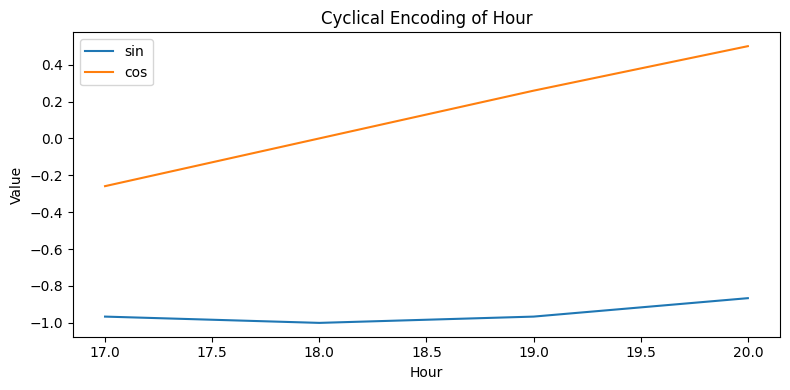

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.plot(df["hour"][:24], df["hour_sin"][:24], label="sin")
plt.plot(df["hour"][:24], df["hour_cos"][:24], label="cos")

plt.title("Cyclical Encoding of Hour")
plt.xlabel("Hour")
plt.ylabel("Value")
plt.legend()

plt.tight_layout()
plt.show()

In [5]:
print("New dataset shape:", df.shape)

new_columns = [
    "hour",
    "day",
    "month",
    "day_of_week",
    "is_weekend",
    "week_of_year",
    "hour_sin",
    "hour_cos"
]

print(new_columns)

New dataset shape: (19729, 36)
['hour', 'day', 'month', 'day_of_week', 'is_weekend', 'week_of_year', 'hour_sin', 'hour_cos']


In [6]:
# Historical consumption lags
df["lag_10min"] = df["Appliances"].shift(1)
df["lag_20min"] = df["Appliances"].shift(2)
df["lag_30min"] = df["Appliances"].shift(3)

df["lag_1hour"] = df["Appliances"].shift(6)
df["lag_2hours"] = df["Appliances"].shift(12)

df["lag_1day"] = df["Appliances"].shift(144)
df["lag_1week"] = df["Appliances"].shift(1008)

print("Lag features created successfully.")

df[
    [
        "date",
        "Appliances",
        "lag_10min",
        "lag_20min",
        "lag_30min",
        "lag_1hour",
        "lag_2hours",
        "lag_1day",
        "lag_1week"
    ]
].head(1010).tail(10)

Lag features created successfully.


,date,Appliances,lag_10min,lag_20min,lag_30min,lag_1hour,lag_2hours,lag_1day,lag_1week
1000,2016-01-18 15:40:00,30,30.0,20.0,30.0,40.0,50.0,80.0,NaN
1001,2016-01-18 15:50:00,40,30.0,30.0,20.0,50.0,50.0,80.0,NaN
1002,2016-01-18 16:00:00,50,40.0,30.0,30.0,50.0,40.0,90.0,NaN
1003,2016-01-18 16:10:00,50,50.0,40.0,30.0,30.0,40.0,80.0,NaN
1004,2016-01-18 16:20:00,50,50.0,50.0,40.0,20.0,40.0,80.0,NaN
1005,2016-01-18 16:30:00,40,50.0,50.0,50.0,30.0,40.0,80.0,NaN
1006,2016-01-18 16:40:00,40,40.0,50.0,50.0,30.0,40.0,80.0,NaN
1007,2016-01-18 16:50:00,50,40.0,40.0,50.0,40.0,50.0,80.0,NaN
1008,2016-01-18 17:00:00,40,50.0,40.0,40.0,50.0,50.0,90.0,60.0
1009,2016-01-18 17:10:00,40,40.0,50.0,40.0,50.0,30.0,130.0,60.0


In [ ]:
past_consumption = df["Appliances"].shift(1)

df["rolling_mean_30min"] = past_consumption.rolling(window=3).mean()
df["rolling_std_30min"] = past_consumption.rolling(window=3).std()

df["rolling_mean_1hour"] = past_consumption.rolling(window=6).mean()
df["rolling_std_1hour"] = past_consumption.rolling(window=6).std()

df["rolling_mean_2hours"] = past_consumption.rolling(window=12).mean()
df["rolling_std_2hours"] = past_consumption.rolling(window=12).std()

print("Rolling features created successfully.")

Rolling features created successfully.


In [8]:
df[
    [
        "date",
        "Appliances",
        "lag_10min",
        "rolling_mean_30min",
        "rolling_std_30min",
        "rolling_mean_1hour",
        "rolling_std_1hour",
        "rolling_mean_2hours",
        "rolling_std_2hours"
    ]
].iloc[15:25]

,date,Appliances,lag_10min,rolling_mean_30min,rolling_std_30min,rolling_mean_1hour,rolling_std_1hour,rolling_mean_2hours,rolling_std_2hours
15,2016-01-11 19:30:00,100,100.0,260.000000,165.227116,276.666667,196.129209,166.666667,175.205507
16,2016-01-11 19:40:00,90,100.0,150.000000,86.602540,281.666667,190.096467,170.833333,172.756178
17,2016-01-11 19:50:00,70,90.0,96.666667,5.773503,258.333333,205.661534,173.333333,171.216680
18,2016-01-11 20:00:00,80,70.0,86.666667,15.275252,173.333333,141.515606,175.000000,170.000000
19,2016-01-11 20:10:00,140,80.0,80.000000,10.000000,115.000000,67.156534,176.666667,168.864299
20,2016-01-11 20:20:00,120,140.0,96.666667,37.859389,96.666667,24.221203,183.333333,165.382935
21,2016-01-11 20:30:00,190,120.0,113.333333,30.550505,100.000000,26.076810,188.333333,162.191432
22,2016-01-11 20:40:00,110,190.0,150.000000,36.055513,115.000000,45.055521,198.333333,157.874135
23,2016-01-11 20:50:00,110,110.0,140.000000,43.588989,118.333333,43.550737,188.333333,159.478316
24,2016-01-11 21:00:00,110,110.0,136.666667,46.188022,125.000000,37.282704,149.166667,101.842868


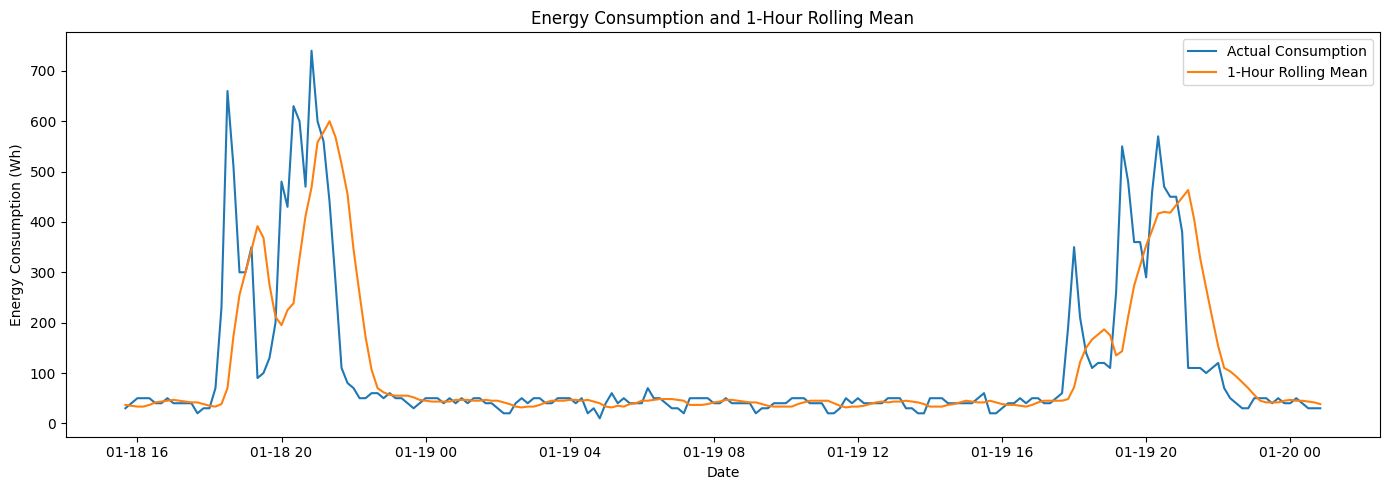

In [9]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["date"].iloc[1000:1200],
    df["Appliances"].iloc[1000:1200],
    label="Actual Consumption"
)

plt.plot(
    df["date"].iloc[1000:1200],
    df["rolling_mean_1hour"].iloc[1000:1200],
    label="1-Hour Rolling Mean"
)

plt.title("Energy Consumption and 1-Hour Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (Wh)")
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
weather_features = [
    "T_out",
    "RH_out",
    "Windspeed",
    "Visibility",
    "Press_mm_hg",
    "Tdewpoint"
]

print("Weather features:")
for feature in weather_features:
    print("-", feature)

Weather features:
- T_out
- RH_out
- Windspeed
- Visibility
- Press_mm_hg
- Tdewpoint


In [11]:
df["T_out_change_1h"] = df["T_out"] - df["T_out"].shift(6)
df["RH_out_change_1h"] = df["RH_out"] - df["RH_out"].shift(6)

print("Weather change features created successfully.")

Weather change features created successfully.


In [ ]:
print("Current dataset shape:", df.shape)

engineered_features = [
    "hour",
    "day",
    "month",
    "day_of_week",
    "is_weekend",
    "week_of_year",
    "hour_sin",
    "hour_cos",
    "lag_10min",
    "lag_20min",
    "lag_30min",
    "lag_1hour",
    "lag_2hours",
    "lag_1day",
    "lag_1week",
    "rolling_mean_30min",
    "rolling_std_30min",
    "rolling_mean_1hour",
    "rolling_std_1hour",
    "rolling_mean_2hours",
    "rolling_std_2hours",
    "T_out_change_1h",
    "RH_out_change_1h"
]

print("\nEngineered features:", len(engineered_features))

missing_features = [
    feature for feature in engineered_features
    if feature not in df.columns
]

print("Missing engineered features:", missing_features)

Current dataset shape: (19729, 51)

Engineered features: 23
Missing engineered features: []


In [13]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(
    ascending=False
)

print("Columns containing missing values:")
print(missing_values)

Columns containing missing values:
lag_1week              1008
lag_1day                144
lag_2hours               12
rolling_mean_2hours      12
rolling_std_2hours       12
lag_1hour                 6
rolling_mean_1hour        6
rolling_std_1hour         6
T_out_change_1h           6
RH_out_change_1h          6
lag_30min                 3
rolling_mean_30min        3
rolling_std_30min         3
lag_20min                 2
lag_10min                 1
dtype: int64


In [ ]:
rows_before = len(df)

df_model = df.dropna().reset_index(drop=True)

rows_after = len(df_model)

print("Rows before:", rows_before)
print("Rows after:", rows_after)
print("Rows removed:", rows_before - rows_after)

print("\nRemaining missing values:")
print(df_model.isnull().sum().sum())

Rows before: 19729
Rows after: 18721
Rows removed: 1008

Remaining missing values:
0


In [15]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(
    ascending=False
)

print("Columns containing missing values:")
print(missing_values)

Columns containing missing values:
lag_1week              1008
lag_1day                144
lag_2hours               12
rolling_mean_2hours      12
rolling_std_2hours       12
lag_1hour                 6
rolling_mean_1hour        6
rolling_std_1hour         6
T_out_change_1h           6
RH_out_change_1h          6
lag_30min                 3
rolling_mean_30min        3
rolling_std_30min         3
lag_20min                 2
lag_10min                 1
dtype: int64


In [16]:
rows_before = len(df)

df_model = df.dropna().reset_index(drop=True)

rows_after = len(df_model)

print("Rows before:", rows_before)
print("Rows after:", rows_after)
print("Rows removed:", rows_before - rows_after)

print("\nRemaining missing values:")
print(df_model.isnull().sum().sum())

Rows before: 19729
Rows after: 18721
Rows removed: 1008

Remaining missing values:
0


In [ ]:
n = len(df_model)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train = df_model.iloc[:train_end].copy()
validation = df_model.iloc[train_end:validation_end].copy()
test = df_model.iloc[validation_end:].copy()

print("Total observations:", n)
print("Training observations:", len(train))
print("Validation observations:", len(validation))
print("Test observations:", len(test))

Total observations: 18721
Training observations: 13104
Validation observations: 2808
Test observations: 2809


In [18]:
print("TRAIN")
print("Start:", train["date"].min())
print("End:  ", train["date"].max())

print("\nVALIDATION")
print("Start:", validation["date"].min())
print("End:  ", validation["date"].max())

print("\nTEST")
print("Start:", test["date"].min())
print("End:  ", test["date"].max())

TRAIN
Start: 2016-01-18 17:00:00
End:   2016-04-18 16:50:00

VALIDATION
Start: 2016-04-18 17:00:00
End:   2016-05-08 04:50:00

TEST
Start: 2016-05-08 05:00:00
End:   2016-05-27 17:00:00


In [19]:
print(
    "Train ends before validation starts:",
    train["date"].max() < validation["date"].min()
)

print(
    "Validation ends before test starts:",
    validation["date"].max() < test["date"].min()
)

Train ends before validation starts: True
Validation ends before test starts: True


In [ ]:
target_column = "target_energy"

excluded_columns = ["date", target_column]

X_train = train.drop(columns=excluded_columns)
y_train = train[target_column]

X_validation = validation.drop(columns=excluded_columns)
y_validation = validation[target_column]

X_test = test.drop(columns=excluded_columns)
y_test = test[target_column]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_validation shape:", X_validation.shape)
print("y_validation shape:", y_validation.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (13104, 49)
y_train shape: (13104,)
X_validation shape: (2808, 49)
y_validation shape: (2808,)
X_test shape: (2809, 49)
y_test shape: (2809,)


In [24]:
print("Number of features:", len(X_train.columns))

print("\nFeature list:")
for i, feature in enumerate(X_train.columns, start=1):
    print(f"{i:02d}. {feature}")

Number of features: 49

Feature list:
01. Appliances
02. lights
03. T1
04. RH_1
05. T2
06. RH_2
07. T3
08. RH_3
09. T4
10. RH_4
11. T5
12. RH_5
13. T6
14. RH_6
15. T7
16. RH_7
17. T8
18. RH_8
19. T9
20. RH_9
21. T_out
22. Press_mm_hg
23. RH_out
24. Windspeed
25. Visibility
26. Tdewpoint
27. hour
28. day
29. month
30. day_of_week
31. is_weekend
32. week_of_year
33. hour_sin
34. hour_cos
35. lag_10min
36. lag_20min
37. lag_30min
38. lag_1hour
39. lag_2hours
40. lag_1day
41. lag_1week
42. rolling_mean_30min
43. rolling_std_30min
44. rolling_mean_1hour
45. rolling_std_1hour
46. rolling_mean_2hours
47. rolling_std_2hours
48. T_out_change_1h
49. RH_out_change_1h


In [25]:
print("Target present in X_train:",
      target_column in X_train.columns)

print("Date present in X_train:",
      "date" in X_train.columns)
print("Train feature columns == Validation feature columns:",
      list(X_train.columns) == list(X_validation.columns))

print("Train feature columns == Test feature columns:",
      list(X_train.columns) == list(X_test.columns))

Target present in X_train: False
Date present in X_train: False
Train feature columns == Validation feature columns: True
Train feature columns == Test feature columns: True


In [26]:
print("TRAIN TARGET")
print(y_train.describe())

print("\nVALIDATION TARGET")
print(y_validation.describe())

print("\nTEST TARGET")
print(y_test.describe())

TRAIN TARGET
count    13104.000000
mean        97.673230
std        104.766199
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1070.000000
Name: target_energy, dtype: float64

VALIDATION TARGET
count    2808.000000
mean       92.781339
std        89.497624
min        20.000000
25%        50.000000
50%        60.000000
75%        90.000000
max       870.000000
Name: target_energy, dtype: float64

TEST TARGET
count    2809.000000
mean       97.027412
std        91.455232
min        20.000000
25%        50.000000
50%        60.000000
75%       100.000000
max       850.000000
Name: target_energy, dtype: float64


In [27]:
import os

os.makedirs("../data/processed", exist_ok=True)

train.to_csv(
    "../data/processed/train_features.csv",
    index=False
)

validation.to_csv(
    "../data/processed/validation_features.csv",
    index=False
)

test.to_csv(
    "../data/processed/test_features.csv",
    index=False
)

print("Feature-engineered datasets saved successfully.")

Feature-engineered datasets saved successfully.
